# Practice: Ray Theory

> **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS164/blob/main/notebooks/04_ray_theory_practice.ipynb)


## Learning objectives:
This notebook is designed to help you build intuition for:

- ray paths
- slowness, ray parameters, travel time curve, and delay times
- how velocity structure controls wave propagation

The goal is to understand the **geometry and physics**, not to do heavy derivations.

**Prerequisites:** Geometry

**Reference:** Shearer, Chapter 4 (Ray Theory: Travel Times)

**Notebook Outline:**
- [Part (a): Computing T(p) and X(p) by Hand](#part-a-computing-x-p-and-t-p-by-hand)
- [Part (b): Travel Time Curve in a Velocity Gradient](#part-b-travel-time-curves-in-a-velocity-gradient)
- [Part (c): Plotting the Velocity Model, Travel-Time Curve, and Delay Time](#part-c-plotting-the-velocity-model-travel-time-curve-and-delay-time)

In [1]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

Running in local environment
✓ numpy is already installed
✓ matplotlib is already installed

✓ All required packages are installed!


## Part (a): Computing $X(p)$ and $T(p)$ by hand

Consider a homogeneous three-layer model with the following properties:

- Layer thicknesses: 2 km, 4 km, and 3 km
- Velocities: 3.5 km/s, 5.5 km/s, and 7.0 km/s

Compute the **surface-to-surface distance** and **travel time** for a ray with
$$
p = 0.18 \ \text{s/km}
$$

### Step 1: Fill out the model

Complete the table below. Recall that slowness is:
$$
u = \frac{1}{v}
$$

| Layer | Depths (km) | Thickness $\Delta z$ (km)  | Velocity $v$ (km/s) | Slowness $u$ (s/km) | $u_i > p$? |
|-------|-------------|----------------------------|-------------|----------------------|-------------|
| 1     |             |                            |             |                      |             |
| 2     |             |                            |             |                      |             |
| 3     |             |                            |             |                      |             |

## Questions:
1. Which layers satisfy $u_i > p$?
2. In which layer does the ray turn?

In [2]:
# Step 2: Compute surface-to-surface distance X(p)

import numpy as np

# Given values (fill in from your table)
p =   # s/km

# Slowness values (compute these from velocities)
u1 =
u2 =

# Layer thicknesses (km)
z1 =
z2 =

# --- Fill in the expressions below ---

layer_1_distance =    #
layer_2_distance =    #

X = 2 * p * (layer_1_distance + layer_2_distance)

print("Surface-to-surface distance X(p) =", X, "km")


SyntaxError: invalid syntax (541720662.py, line 6)

In [3]:
# Step 3: Compute surface-to-surface travel time T(p)

# --- Fill in the expressions below ---

layer_1_tt =    #
layer_2_tt =   #

T = 2 * (layer_1_tt + layer_2_tt)

print("Surface-to-surface travel time T(p) =", T, "s")

SyntaxError: invalid syntax (2032232158.py, line 5)

## Questions
1. Does your result make physical sense?
2. Is the travel time consistent with the velocities in the model?

Recall that the delay time is given by:
$$
\tau(p) = 2 \sum_i \sqrt{u_i^2 - p^2}\, \Delta z_i
$$

In [6]:
### Step 4: Compute $\tau(p)$

## Using the same layers that satisfied $u_i > p$, compute:

# --- Fill in the expressions below ---

layer_1_tau =    #
layer_2_tau =    #

tau = 2 * (layer_1_tau + layer_2_tau)

print("Delay time tau(p) =", tau, "s")

---

### Step 5: Verify the relationship

## Recall: T(p) = pX(p) + \tau(p) or equivalently \tau(p) = T(p) - pX(p)

Compute:

tau_check = T - p * X

print("Tau from T - pX =", tau_check, "s")


SyntaxError: invalid syntax (3776201482.py, line 5)

## Questions

1. What value do you obtain for $\tau(p)$ from the integral expression?
2. What value do you obtain from $T - pX$?
3. Do the two results agree?
4. What does this tell you about how travel time is partitioned?

## Part (b): Travel-Time Curves in a Velocity Gradient

In this exercise, you will explore how seismic travel times depend on Earth structure using a simple model in which velocity increases linearly with depth:
$$
v(z)=v_0+gz
$$
In such a model, seismic rays bend smoothly due to the continuous velocity gradient. Rays that travel farther distances penetrate deeper into the Earth, where velocities are higher. As a result, the travel-time curve (travel time vs. distance) is not a straight line, but instead reflects the changing velocity structure with depth.

In the plot:
- The left panel shows the velocity model as a function of depth
- The right panel shows the travel-time curve. Points are colored by ray parameter, which controls the angle and depth of each ray.
- Points are color-coded by the ray parameter.

Your goal is to interpret the shape of the travel-time curve and understand how it relates to the underlying velocity structure.

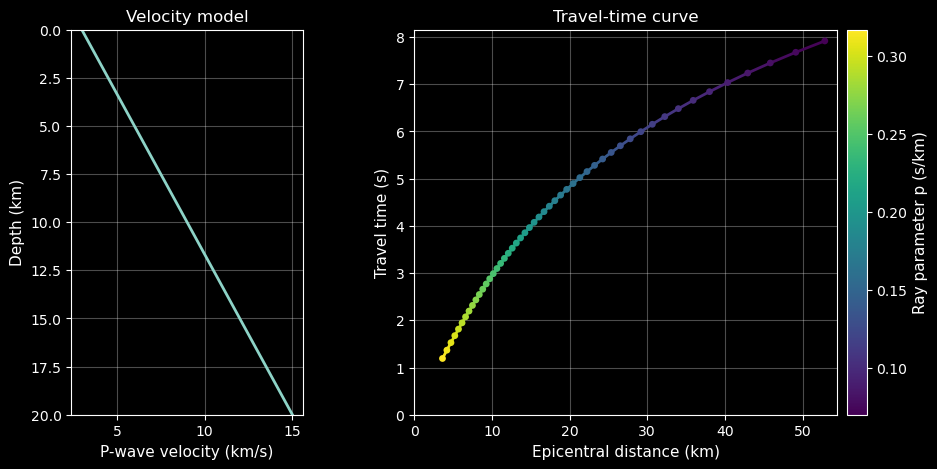

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import colors

# -------------------------------------------------
# Adjustable model parameters
# -------------------------------------------------
v0 = 3.0          # surface velocity (km/s)
g = 0.6           # velocity gradient dv/dz (km/s per km)
zmax = 20.0       # maximum depth shown (km)
n_rays = 60       # number of rays
eps = 1e-8        # small number to avoid divide-by-zero near turning points

# -------------------------------------------------
# Velocity model: v(z) = v0 + g z
# -------------------------------------------------
z = np.linspace(0.0, zmax, 4000)
v = v0 + g * z

# Only use ray parameters safely below the critical value 1/v0
p_min = 0.02
p_max = 0.95 / v0
p_vals = np.linspace(p_min, p_max, n_rays)

x_all = []
t_all = []
valid_p = []

for p in p_vals:
    # Turning depth from p * v(z_turn) = 1
    z_turn = (1.0 / p - v0) / g

    # Skip nonphysical or out-of-range rays
    if not np.isfinite(z_turn) or z_turn <= 0.0 or z_turn >= zmax:
        continue

    # Do not integrate exactly to the turning point, where denominator -> 0
    z_ray = np.linspace(0.0, z_turn * (1.0 - 1e-6), 2000)
    v_ray = v0 + g * z_ray

    arg = 1.0 - (p * v_ray) ** 2

    # Remove any bad points caused by roundoff
    mask = np.isfinite(arg) & (arg > eps)
    if np.count_nonzero(mask) < 10:
        continue

    z_ray = z_ray[mask]
    v_ray = v_ray[mask]
    arg = arg[mask]

    denom = np.sqrt(arg)

    dx_dz = (p * v_ray) / denom
    dt_dz = 1.0 / (v_ray * denom)

    # Final sanity check
    finite_mask = np.isfinite(dx_dz) & np.isfinite(dt_dz) & np.isfinite(z_ray)
    if np.count_nonzero(finite_mask) < 10:
        continue

    z_ray = z_ray[finite_mask]
    dx_dz = dx_dz[finite_mask]
    dt_dz = dt_dz[finite_mask]

    x = 2.0 * np.trapezoid(dx_dz, z_ray)
    t = 2.0 * np.trapezoid(dt_dz, z_ray)

    if np.isfinite(x) and np.isfinite(t):
        x_all.append(x)
        t_all.append(t)
        valid_p.append(p)

x_all = np.array(x_all)
t_all = np.array(t_all)
valid_p = np.array(valid_p)

# Sort by distance
idx = np.argsort(x_all)
x_all = x_all[idx]
t_all = t_all[idx]
valid_p = valid_p[idx]

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig = plt.figure(figsize=(11, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 2.2], wspace=0.30)

# Left panel: velocity model
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(v, z, linewidth=2)
ax1.set_ylim(zmax, 0)
ax1.set_xlabel("P-wave velocity (km/s)", fontsize=11)
ax1.set_ylabel("Depth (km)", fontsize=11)
ax1.set_title("Velocity model", fontsize=12)
ax1.grid(True, alpha=0.3)

# Right panel: travel-time curve
ax2 = fig.add_subplot(gs[0, 1])

if len(x_all) > 1:
    points = np.array([x_all, t_all]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = colors.Normalize(vmin=valid_p.min(), vmax=valid_p.max())
    lc = LineCollection(segments, cmap="viridis", norm=norm)
    lc.set_array(0.5 * (valid_p[:-1] + valid_p[1:]))
    lc.set_linewidth(2.0)
    ax2.add_collection(lc)

sc = ax2.scatter(x_all, t_all, c=valid_p, cmap="viridis", s=24, edgecolor="none", zorder=3)

ax2.set_xlim(0, 1.03 * np.nanmax(x_all))
ax2.set_ylim(0, 1.03 * np.nanmax(t_all))
ax2.set_xlabel("Epicentral distance (km)", fontsize=11)
ax2.set_ylabel("Travel time (s)", fontsize=11)
ax2.set_title("Travel-time curve", fontsize=12)
ax2.grid(True, alpha=0.3)

cbar = plt.colorbar(sc, ax=ax2, pad=0.02)
cbar.set_label("Ray parameter p (s/km)", fontsize=11)

plt.show()

## Questions

1. At small distances, what does the slope of the travel-time curve represent? How does this relate to the near-surface velocity?
2. Is the travel-time curve concave up or concave down? What does this tell you about how velocity changes with depth?
3. Which rays (high or low ray parameter) travel deeper into the Earth? How can you tell from the plot?
4. Increase the surface velocity $v_0$. How does this affect the slope of the curve at small distances and the overall travel times?
5. Increase the velocity gradient $g$. How does this change the curvature of the travel-time curve?
6. Which parts of the travel-time curve are most sensitive to shallow structure versus deeper structure?

## Part (c): Plotting the Velocity Model, Travel-Time Curve, and Delay Time

In this exercise, you will use a layered velocity model to compute and visualize:

- velocity as a function of depth
- the travel-time curve $T(X)$
- the delay time $\tau(p)$ as a function of ray parameter

Use the same three-layer model as before:

- Layer thicknesses: 2 km, 4 km, and 3 km
- Velocities: 3.5 km/s, 5.5 km/s, and 7.0 km/s

Recall:

$$
u_i = \frac{1}{v_i}
$$

$$
X(p) = 2p \sum_i \frac{\Delta z_i}{\sqrt{u_i^2 - p^2}}, \qquad u_i > p
$$

$$
T(p) = 2 \sum_i \frac{u_i^2 \Delta z_i}{\sqrt{u_i^2 - p^2}}, \qquad u_i > p
$$

$$
\tau(p) = 2 \sum_i \sqrt{u_i^2 - p^2}\,\Delta z_i, \qquad u_i > p
$$

Only include layers for which $u_i > p$.

## Your tasks

1. Plot the velocity model as a step function versus depth.
2. Write a function that computes $X(p)$, $T(p)$, and $\tau(p)$ for a single value of $p$.
3. Evaluate that function over a range of ray parameters.
4. Plot:
   - $T$ versus $X$
   - $\tau$ versus $p$
5. Verify numerically that:
$$
\tau(p) = T(p) - pX(p)
$$

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Model definition
# ---------------------------------
thicknesses = np.array([2.0, 4.0, 3.0])   # km
velocities = np.array([3.5, 5.5, 7.0])    # km/s

# TODO: compute slownesses
slownesses =

# ---------------------------------
# Part 1: Plot velocity with depth
# ---------------------------------
# TODO: define the depth coordinates for a step plot
depth_edges =

# One simple way to make a step plot is to repeat values
velocity_plot =
depth_plot =

plt.figure(figsize=(5, 6))
plt.plot(velocity_plot, depth_plot)
plt.gca().invert_yaxis()
plt.xlabel("Velocity (km/s)")
plt.ylabel("Depth (km)")
plt.title("Velocity Model")
plt.grid(True)
plt.show()

# ---------------------------------
# Part 2: Function to compute X, T, tau
# ---------------------------------
def ray_quantities(p, u, dz):
    """
    Compute X(p), T(p), and tau(p) for a layered model.

    Parameters
    ----------
    p : float
        Ray parameter (s/km)
    u : array
        Layer slownesses (s/km)
    dz : array
        Layer thicknesses (km)

    Returns
    -------
    X, T, tau : floats
    """
    # TODO: identify which layers satisfy u_i > p
    # Example:
    # if u = [0.28, 0.18, 0.14] and p = 0.16
    # then mask should be: [True, True, False]
    mask =

    # If no layers contribute, return NaNs
    if not np.any(mask):
        return np.nan, np.nan, np.nan

    u_use = u[mask]
    dz_use = dz[mask]

    # TODO: compute sqrt(u_i^2 - p^2)
    sqrt_term =

    # TODO: compute X(p)
    X =

    # TODO: compute T(p)
    T =

    # TODO: compute tau(p)
    tau =

    return X, T, tau

# ---------------------------------
# Part 3: Loop over ray parameters
# ---------------------------------
# Avoid using the exact slowness values to prevent divide-by-zero
p_min = 0.01
p_max = np.max(slownesses) * 0.999

p_values = np.linspace(0.01, 0.99 * np.max(slownesses), 200)

X_values = []
T_values = []
tau_values = []

for p in p_values:
    X, T, tau = ray_quantities(p, slownesses, thicknesses)
    X_values.append(X)
    T_values.append(T)
    tau_values.append(tau)

X_values = np.array(X_values)
T_values = np.array(T_values)
tau_values = np.array(tau_values)

# ---------------------------------
# Part 4: Plot T(X)
# ---------------------------------
plt.figure(figsize=(6, 5))
plt.plot(X_values, T_values)
plt.xlabel("Distance X (km)")
plt.ylabel("Travel Time T (s)")
plt.title("Travel-Time Curve")
plt.grid(True)
plt.show()

# ---------------------------------
# Part 5: Plot tau(p)
# ---------------------------------
plt.figure(figsize=(6, 5))
plt.plot(p_values, tau_values)
plt.xlabel("Ray parameter p (s/km)")
plt.ylabel("Delay time tau(p) (s)")
plt.title("Delay Time Function")
plt.grid(True)
plt.show()

# ---------------------------------
# Part 6: Verify tau = T - pX
# ---------------------------------
tau_check = T_values - p_values * X_values

plt.figure(figsize=(6, 5))
plt.plot(p_values, tau_values, label="tau(p)")
plt.plot(p_values, tau_check, "--", label="T - pX")
plt.xlabel("Ray parameter p (s/km)")
plt.ylabel("Time (s)")
plt.title("Checking tau(p) = T(p) - pX(p)")
plt.grid(True)
plt.legend()
plt.show()

# Print the maximum absolute difference
max_diff = np.nanmax(np.abs(tau_values - tau_check))
print("Maximum absolute difference:", max_diff)

SyntaxError: invalid syntax (2627089817.py, line 11)


## Questions

1. Which layers contribute for small $p$? For large $p$?
2. Does the travel-time curve appear to have multiple branches?
3. How does the $\tau(p)$ curve compare with the $T(X)$ curve?
4. Why is $\tau(p)$ often easier to work with mathematically?